# Project Overview: Predicting Road Accident Risk

**Objective:** To develop a high-performance machine learning model capable of predicting the continuous [0-1] `accident_risk` value, utilizing a comprehensive dataset generated from a deep learning model. This initiative aims to establish accurate risk assessment patterns based on environmental, infrastructural, and temporal variables to support proactive safety evaluations.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s5e10')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s5e10


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import math
import joblib
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e10/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e10/test.csv')

In [4]:
train_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [5]:
test_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   road_type               172585 non-null  object 
 2   num_lanes               172585 non-null  int64  
 3   curvature               172585 non-null  float64
 4   speed_limit             172585 non-null  int64  
 5   lighting                172585 non-null  object 
 6   weather                 172585 non-null  object 
 7   road_signs_present      172585 non-null  bool   
 8   public_road             172585 non-null  bool   
 9   time_of_day             172585 non-null  object 
 10  holiday                 172585 non-null  bool   
 11  school_season           172585 non-null  bool   
 12  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [8]:
train_df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [9]:
test_df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
dtype: int64

## 3. Exploratory Data Analysis

In [10]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,517754.0,258876.500000,149462.849974,0.0,129438.25,258876.50,388314.75,517753.0
num_lanes,517754.0,2.491511,1.120434,1.0,1.00,2.00,3.00,4.0
curvature,517754.0,0.488719,0.272563,0.0,0.26,0.51,0.71,1.0
speed_limit,517754.0,46.112575,15.788521,25.0,35.00,45.00,60.00,70.0
num_reported_accidents,517754.0,1.187970,0.895961,0.0,1.00,1.00,2.00,7.0
accident_risk,517754.0,0.352377,0.166417,0.0,0.23,0.34,0.46,1.0


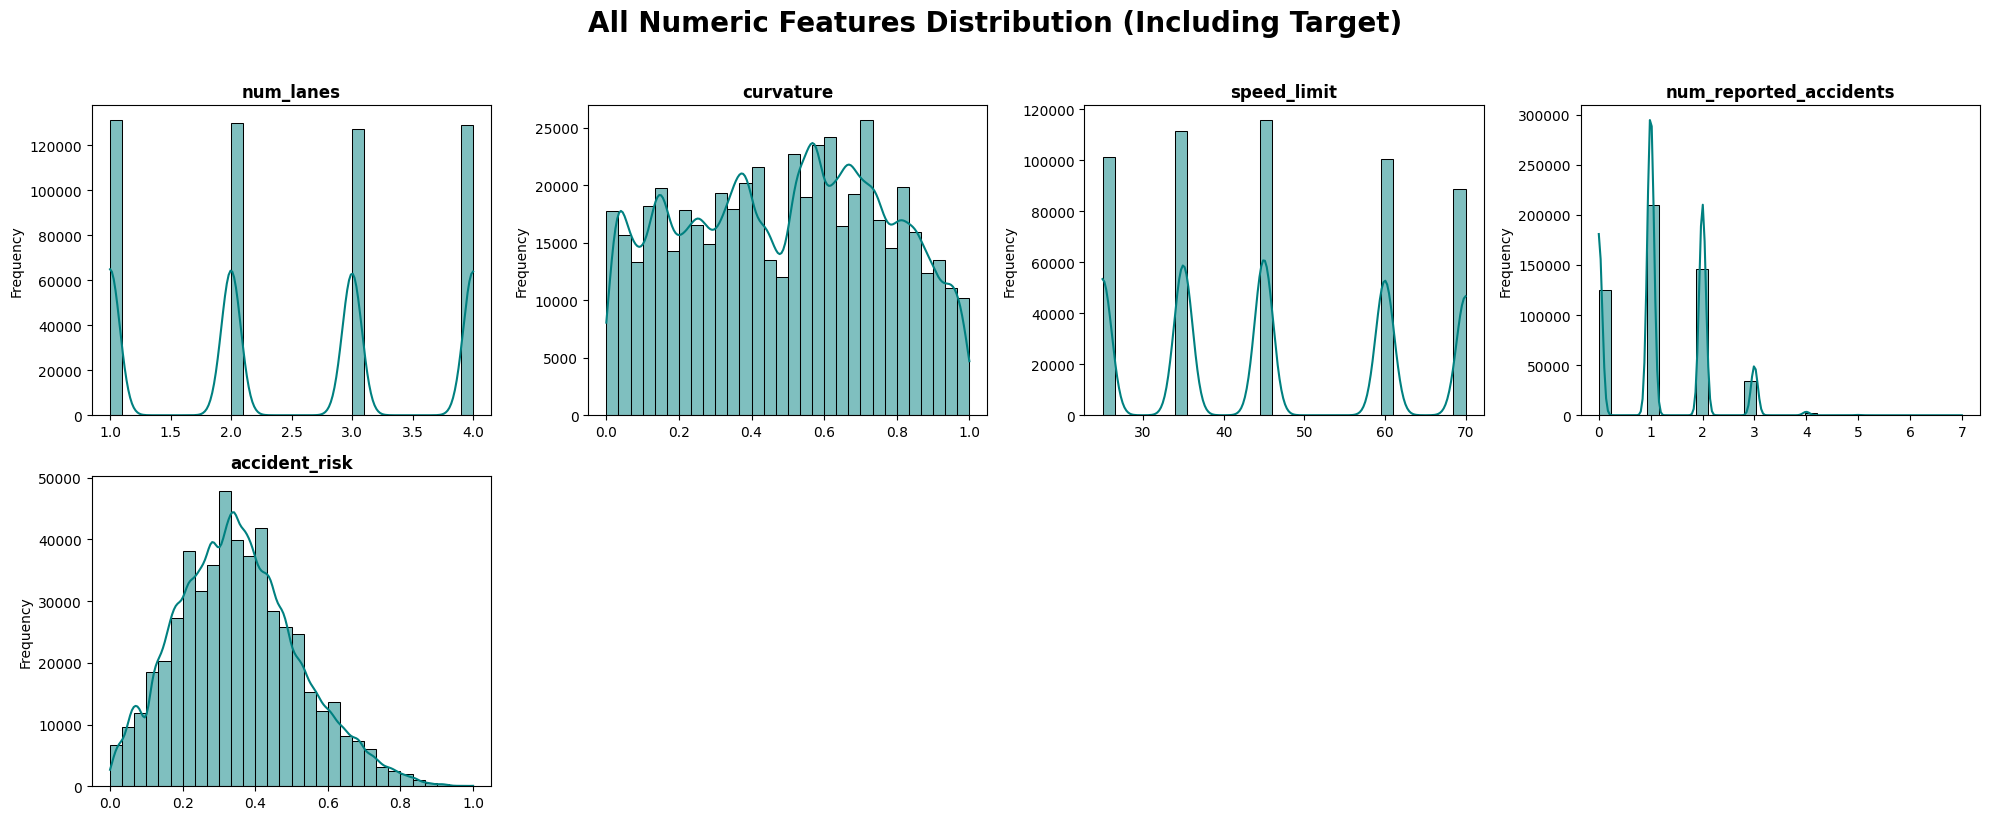

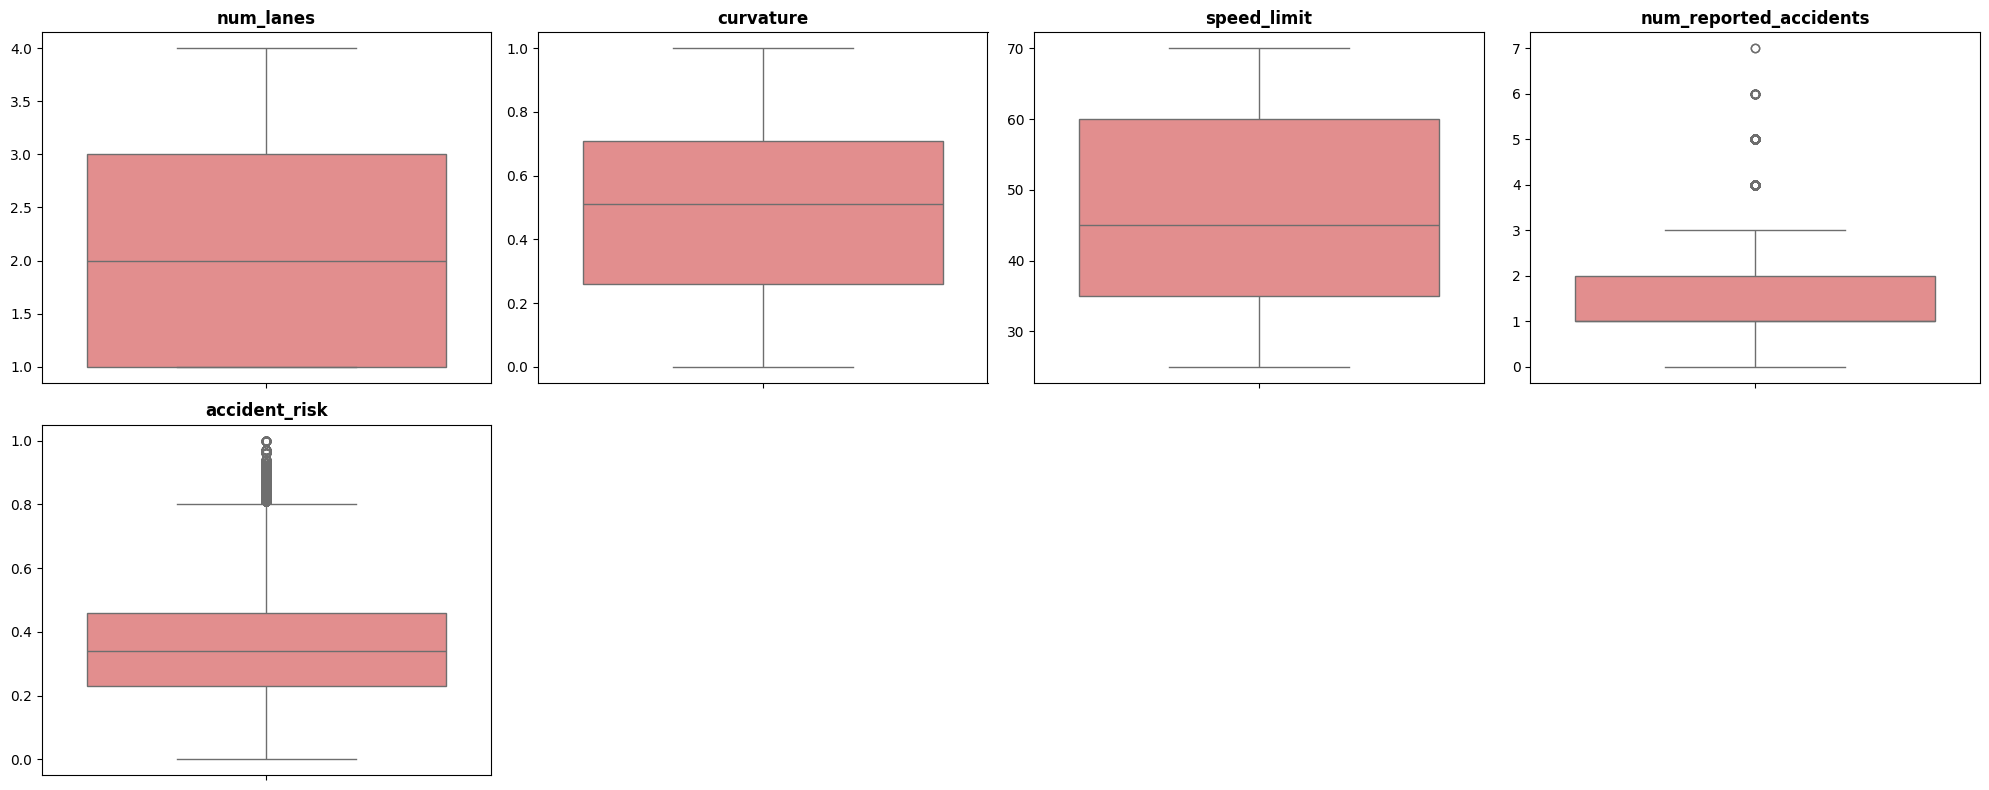

In [11]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore').columns.tolist()

num_plots = len(numeric_cols)
cols_per_row = 4
rows = math.ceil(num_plots / cols_per_row)

# Histogram
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for i in range(num_plots, len(axes)):
    axes[i].axis('off')

plt.suptitle('All Numeric Features Distribution (Including Target)', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=train_df[col].dropna(), ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')

for i in range(num_plots, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

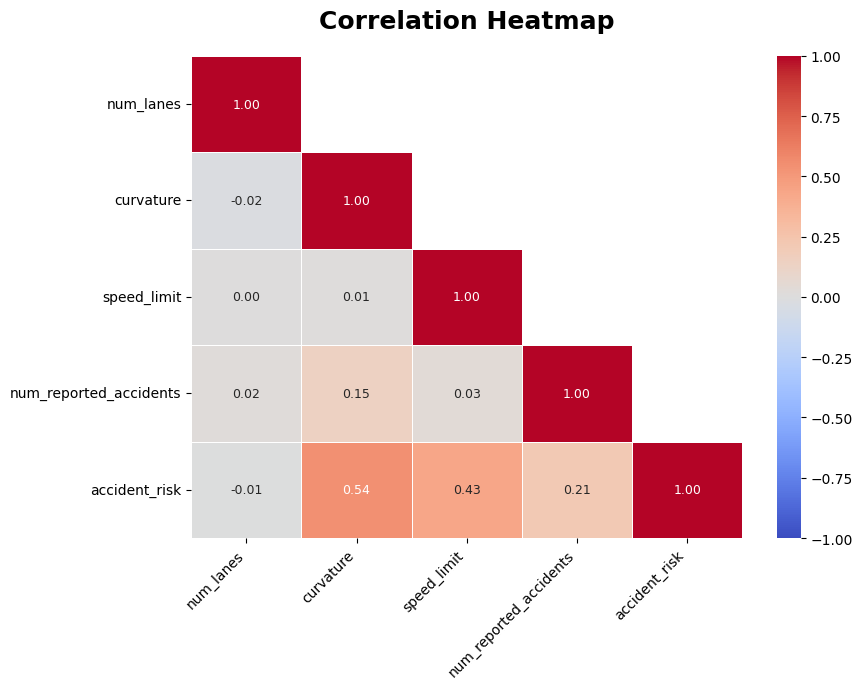

In [12]:
numeric_df = train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore')

corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(9, 7))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f", 
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 9},
            vmax=1.0, vmin=-1.0)

plt.title('Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

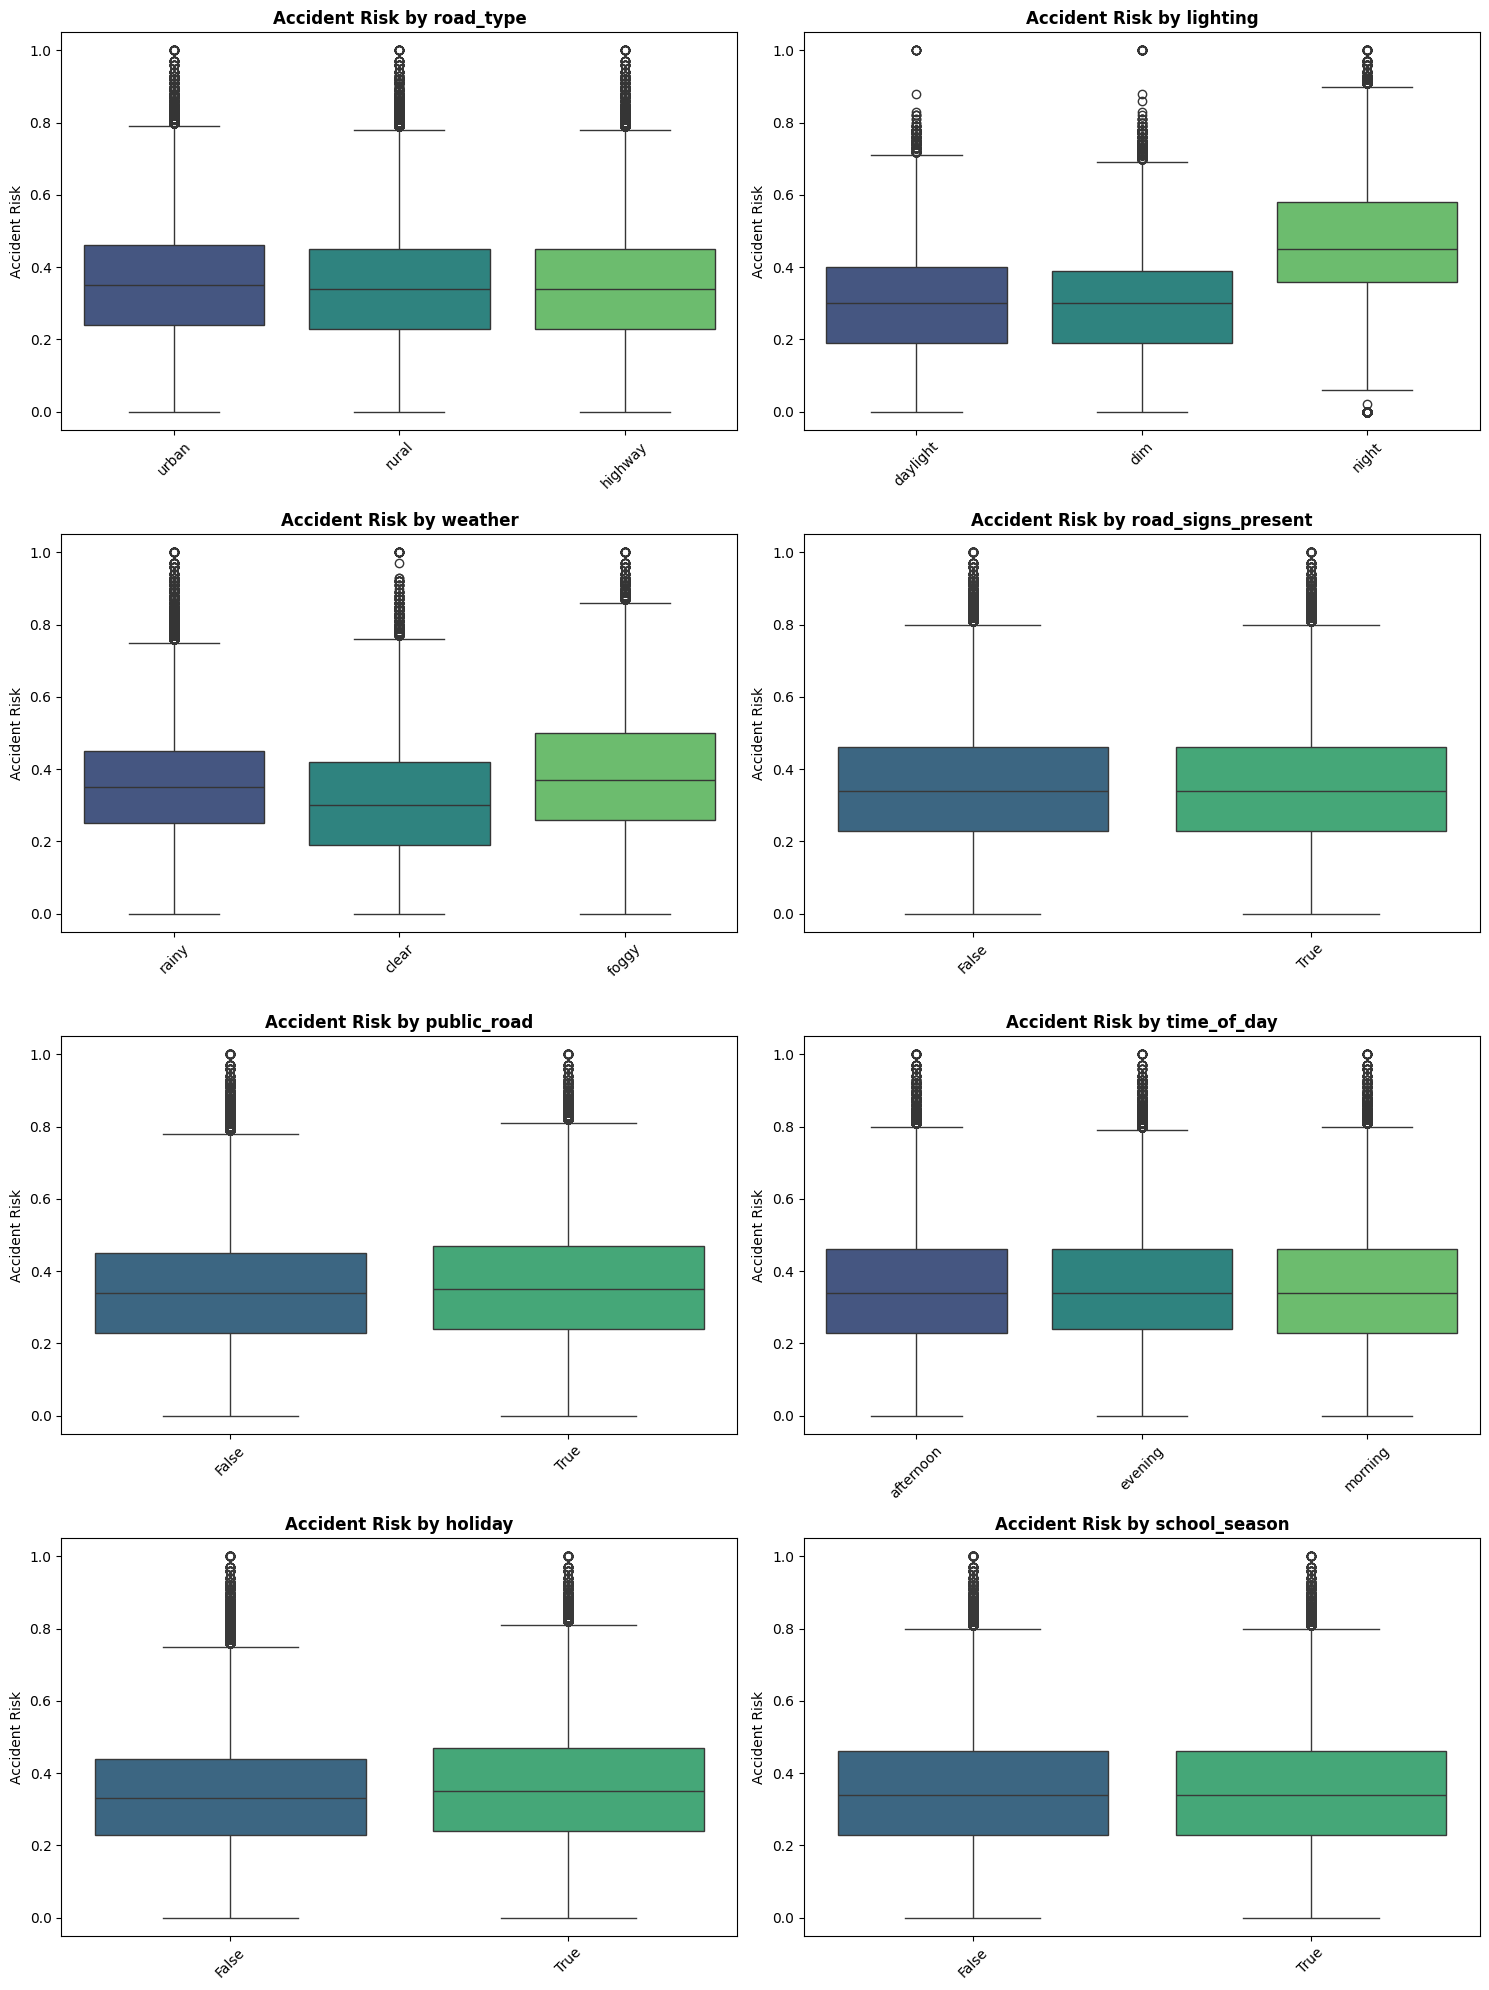

In [13]:
cat_cols = train_df.select_dtypes(include=['object', 'bool']).columns.tolist()

num_plots = len(cat_cols)
cols_per_row = 2 
rows = math.ceil(num_plots / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=train_df, x=col, y='accident_risk', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Accident Risk by {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Accident Risk')

# Boş kalan subplotları kapat
for i in range(num_plots, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [14]:
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

train_df_encoded = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_df_encoded = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

In [15]:
bool_cols = train_df.select_dtypes(include=['bool']).columns

In [16]:
for col in bool_cols:
    train_df_encoded[col] = train_df_encoded[col].astype(int)
    test_df_encoded[col] = test_df_encoded[col].astype(int)

In [17]:
train_df_encoded

,id,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
0,0,2,0.06,35,0,1,0,1,1,0.13,False,True,False,False,False,True,False,False
1,1,4,0.99,35,1,0,1,1,0,0.35,False,True,False,False,False,False,True,False
2,2,4,0.63,70,0,1,1,0,2,0.30,True,False,True,False,False,False,False,True
3,3,4,0.07,35,1,1,0,0,1,0.21,False,False,True,False,False,True,False,True
4,4,1,0.58,60,0,0,1,0,1,0.56,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,4,0.10,70,1,1,0,0,2,0.32,False,False,False,False,True,False,False,False
517750,517750,4,0.47,35,1,1,0,0,1,0.26,True,False,False,False,False,True,False,True
517751,517751,4,0.62,25,0,0,0,1,0,0.19,False,True,False,False,True,False,False,False
517752,517752,3,0.63,25,1,0,1,1,3,0.51,False,False,False,True,False,False,False,False


In [18]:
train_df_encoded.isna().sum().sum()

np.int64(0)

In [19]:
test_df_encoded.isna().sum().sum()

np.int64(0)

In [20]:
train_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   road_signs_present      517754 non-null  int64  
 5   public_road             517754 non-null  int64  
 6   holiday                 517754 non-null  int64  
 7   school_season           517754 non-null  int64  
 8   num_reported_accidents  517754 non-null  int64  
 9   accident_risk           517754 non-null  float64
 10  road_type_rural         517754 non-null  bool   
 11  road_type_urban         517754 non-null  bool   
 12  lighting_dim            517754 non-null  bool   
 13  lighting_night          517754 non-null  bool   
 14  weather_foggy       

In [21]:
test_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   num_lanes               172585 non-null  int64  
 2   curvature               172585 non-null  float64
 3   speed_limit             172585 non-null  int64  
 4   road_signs_present      172585 non-null  int64  
 5   public_road             172585 non-null  int64  
 6   holiday                 172585 non-null  int64  
 7   school_season           172585 non-null  int64  
 8   num_reported_accidents  172585 non-null  int64  
 9   road_type_rural         172585 non-null  bool   
 10  road_type_urban         172585 non-null  bool   
 11  lighting_dim            172585 non-null  bool   
 12  lighting_night          172585 non-null  bool   
 13  weather_foggy           172585 non-null  bool   
 14  weather_rainy       

In [22]:
train_df_encoded['accident_risk'].dtype

dtype('float64')

In [23]:
train_df_encoded['accident_risk'].describe()

count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64

In [24]:
train_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   road_signs_present      517754 non-null  int64  
 5   public_road             517754 non-null  int64  
 6   holiday                 517754 non-null  int64  
 7   school_season           517754 non-null  int64  
 8   num_reported_accidents  517754 non-null  int64  
 9   accident_risk           517754 non-null  float64
 10  road_type_rural         517754 non-null  bool   
 11  road_type_urban         517754 non-null  bool   
 12  lighting_dim            517754 non-null  bool   
 13  lighting_night          517754 non-null  bool   
 14  weather_foggy       

In [25]:
x = train_df_encoded.drop(columns=['id', 'accident_risk'])
y = train_df_encoded['accident_risk']

In [26]:
train_df

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517749,517749,highway,4,0.10,70,daylight,foggy,True,True,afternoon,False,False,2,0.32
517750,517750,rural,4,0.47,35,daylight,rainy,True,True,morning,False,False,1,0.26
517751,517751,urban,4,0.62,25,daylight,foggy,False,False,afternoon,False,True,0,0.19
517752,517752,highway,3,0.63,25,night,clear,True,False,afternoon,True,True,3,0.51


In [27]:
x_test_final = test_df_encoded.drop(columns=['id'], errors='ignore')

## 5. Model Training, Optimization & Deployment Strategy

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import warnings
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

def algo_test(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor(max_iter=2000, random_state=42)
    ETR = ExtraTreeRegressor(random_state=42)
    GBR = GradientBoostingRegressor(random_state=42)
    kn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) 
    ada = AdaBoostRegressor(random_state=42)
    dt = DecisionTreeRegressor(random_state=42)
    xgb = XGBRegressor(n_jobs=-1, random_state=42, tree_method='hist')
    rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    lgbm = LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1)
    cat = CatBoostRegressor(verbose=0, random_state=42)
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, kn, ada, dt, xgb, rf, lgbm, cat]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Extra Tree', 'Gradient Boosting', 'KNeighbors', 'AdaBoost', 
        'Decision Tree', 'XGBRegressor', 'Random Forest', 'LightGBM', 'CatBoost'
    ]
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)
    
    for algo, name in zip(algos, algo_names):
        print(f"Now training and evaluating: {name}...")
        
        algo.fit(x_train_scaled, y_train)
        predictions = algo.predict(x_test_scaled)
        
        r_squared.append(r2_score(y_test, predictions))
        rmse.append(mean_squared_error(y_test, predictions) ** 0.5)
        mae.append(mean_absolute_error(y_test, predictions))
        
    rtable = result.assign(R_Squared=r_squared, RMSE=rmse, MAE=mae).sort_values('R_Squared', ascending=False)
    return rtable

In [29]:
report_table = algo_test(x, y)

Now training and evaluating: Linear...
Now training and evaluating: Ridge...
Now training and evaluating: Lasso...
Now training and evaluating: ElasticNet...
Now training and evaluating: SGD...
Now training and evaluating: Extra Tree...
Now training and evaluating: Gradient Boosting...
Now training and evaluating: KNeighbors...
Now training and evaluating: AdaBoost...
Now training and evaluating: Decision Tree...
Now training and evaluating: XGBRegressor...
Now training and evaluating: Random Forest...
Now training and evaluating: LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Now training and evaluating: CatBoost...


In [30]:
report_table

,R_Squared,RMSE,MAE
CatBoost,0.885357,0.056263,0.043717
XGBRegressor,0.885049,0.056339,0.043746
LightGBM,0.884721,0.056419,0.043834
Gradient Boosting,0.881910,0.057103,0.044453
Random Forest,0.871062,0.059668,0.046311
KNeighbors,0.831744,0.068161,0.052850
Ridge,0.804188,0.073531,0.058312
Linear,0.804188,0.073531,0.058312
SGD,0.804138,0.073540,0.058310
Extra Tree,0.750373,0.083023,0.064122


In [31]:
x_raw_train, x_raw_val, y_raw_train, y_raw_val = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [32]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_raw_train)
x_val_scaled = scaler.transform(x_raw_val)

In [33]:
model=CatBoostRegressor(
    verbose=100,
    random_state=42,
    eval_metric='RMSE'
)

In [34]:
model.fit(x_train_scaled, y_raw_train)

Learning rate set to 0.106096
0:	learn: 0.1522894	total: 36.2ms	remaining: 36.2s
100:	learn: 0.0563850	total: 2.8s	remaining: 25s
200:	learn: 0.0561456	total: 5.55s	remaining: 22.1s
300:	learn: 0.0560077	total: 8.38s	remaining: 19.5s
400:	learn: 0.0559030	total: 11.1s	remaining: 16.6s
500:	learn: 0.0558099	total: 13.9s	remaining: 13.8s
600:	learn: 0.0557289	total: 16.7s	remaining: 11.1s
700:	learn: 0.0556618	total: 19.5s	remaining: 8.31s
800:	learn: 0.0556012	total: 22.3s	remaining: 5.53s
900:	learn: 0.0555365	total: 25s	remaining: 2.75s
999:	learn: 0.0554725	total: 27.8s	remaining: 0us


CatBoostRegressor(eval_metric='RMSE', loss_function='RMSE', random_state=42, verbose=100)

In [35]:
y_pred = model.predict(x_val_scaled)

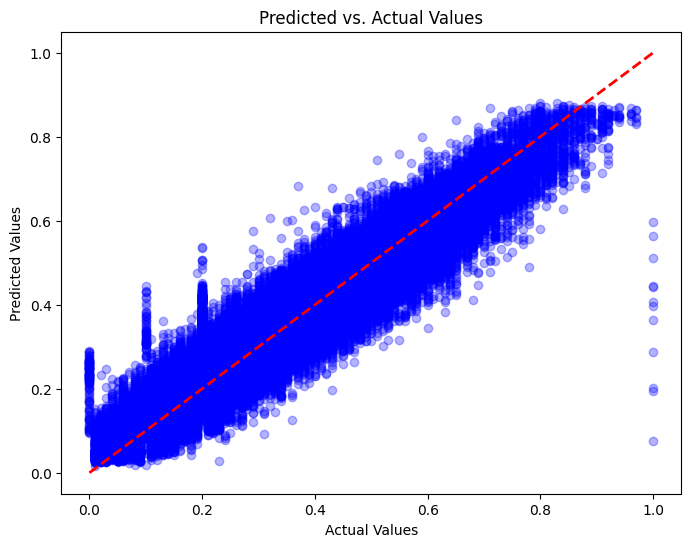

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_raw_val, y_pred, alpha=0.3, color='blue')

plt.plot([y_raw_val.min(), y_raw_val.max()], [y_raw_val.min(), y_raw_val.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Values')
plt.show()

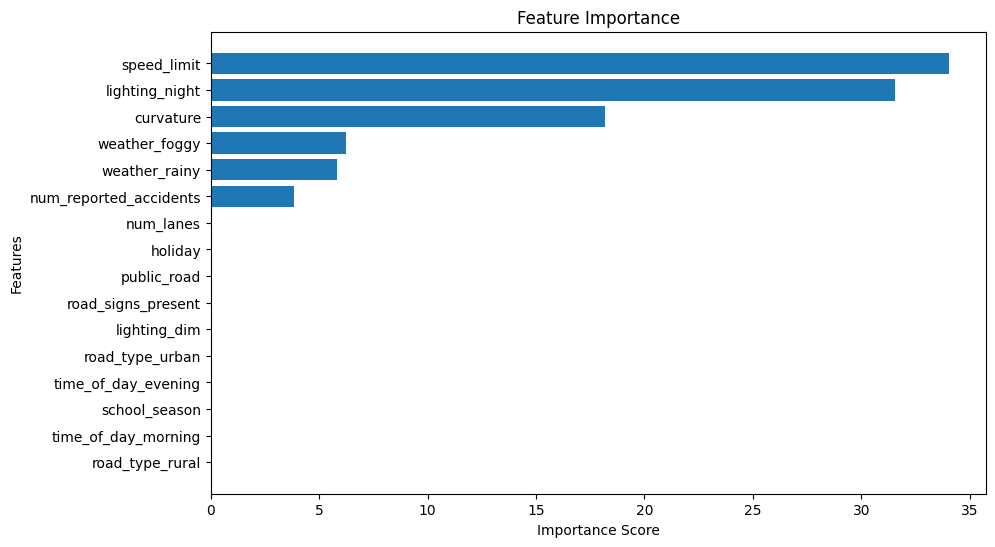

In [37]:
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [x.columns[i] for i in sorted_idx])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

In [38]:
residuals = y_raw_val - y_pred

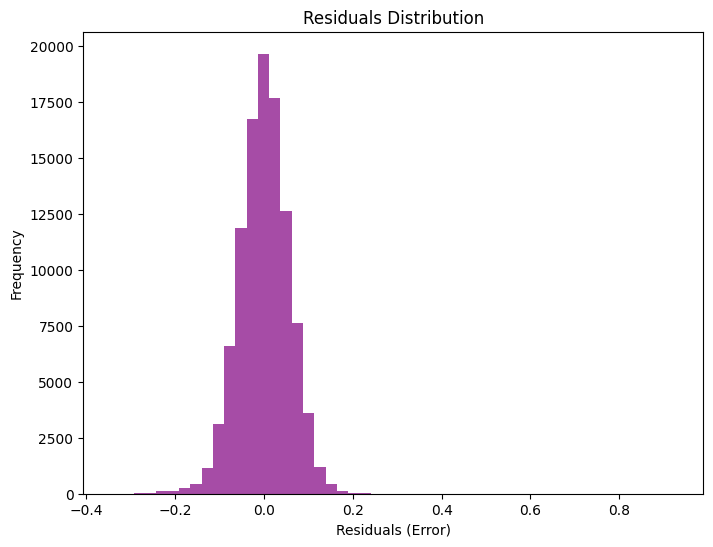

In [39]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=50, color='purple', alpha=0.7)
plt.xlabel('Residuals (Error)')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.show()

In [40]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x_test_final_scaled = scaler.transform(x_test_final)

In [41]:
model.fit(x_scaled, y)

Learning rate set to 0.109903
0:	learn: 0.1517897	total: 46.9ms	remaining: 46.9s
100:	learn: 0.0564227	total: 3.49s	remaining: 31s
200:	learn: 0.0561876	total: 6.97s	remaining: 27.7s
300:	learn: 0.0560569	total: 10.4s	remaining: 24.1s
400:	learn: 0.0559495	total: 13.8s	remaining: 20.6s
500:	learn: 0.0558660	total: 17.4s	remaining: 17.3s
600:	learn: 0.0557991	total: 20.9s	remaining: 13.9s
700:	learn: 0.0557300	total: 24.4s	remaining: 10.4s
800:	learn: 0.0556702	total: 27.9s	remaining: 6.92s
900:	learn: 0.0556152	total: 31.3s	remaining: 3.44s
999:	learn: 0.0555669	total: 34.7s	remaining: 0us


CatBoostRegressor(eval_metric='RMSE', loss_function='RMSE', random_state=42, verbose=100)

In [42]:
final_predictions = model.predict(x_test_final_scaled)

In [43]:
submission = pd.DataFrame({
    'id': test_df['id'], 
    'accident_risk': final_predictions
})
submission.to_csv('submission.csv', index=False)

In [44]:
joblib.dump(model, 'road_accident_catboost_model.joblib')
joblib.dump(scaler, 'road_accident_scaler.joblib')

['road_accident_scaler.joblib']

In [45]:
with open('road_accident_catboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('road_accident_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [46]:
model_columns = x.columns.tolist()

In [47]:
joblib.dump(model_columns, 'model_columns.joblib')

['model_columns.joblib']